# Análisis del Dato
## Comparativa de riesgo y rentabilidad entre banca tradicional y tech financiero (2015–2024)
### Juan Lantero de la Osa — Universidad Francisco de Vitoria

---



---
## 0. Librerías y carga de datos

In [11]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')

# Clustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Árbol de decisión
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix,
                              RocCurveDisplay)

# Test estadístico
from scipy.stats import mannwhitneyu

# Estilo visual — consistente con Ingeniería del Dato
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

COLOR_BANK = '#2980B9'
COLOR_TECH = '#E67E22'
COLORES    = {'Bank': COLOR_BANK, 'Tech Financiero': COLOR_TECH}

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [12]:
# Montar Drive y cargar dataset
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/TFG/DATOS_TFG_LIMPIO.xlsx')

# Limpieza — consistente con Ingeniería del Dato
cols_numericas = ['Precio_acc_EUR','Rentab_Mensual','Rentab_Acumulada','Exceso',
                  'Sharpe ratio','Risk Free Rate','Drawdowns ','EUROSTOXX_Ret',
                  'Beta','Alpha','Volatilidad_Mensual']
for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.rename(columns={'Drawdowns ': 'Drawdowns'})
df = df.dropna(subset=['Empresa']).reset_index(drop=True)

# Subperiodos
def asignar_subperiodo(fecha):
    if fecha <= pd.Timestamp('2019-12-01'):   return 'Tipos bajos (2015-2019)'
    elif fecha <= pd.Timestamp('2021-12-01'): return 'COVID-19 (2020-2021)'
    else:                                      return 'Subida de tipos (2022-2024)'

df['Subperiodo']     = df['Fecha'].apply(asignar_subperiodo)
df['Subperiodo_num'] = df['Subperiodo'].map({
    'Tipos bajos (2015-2019)': 0,
    'COVID-19 (2020-2021)': 1,
    'Subida de tipos (2022-2024)': 2
})

# Variable objetivo para el árbol
mediana_mes          = df.groupby('Fecha')['Sharpe ratio'].transform('median')
df['Sharpe_Superior'] = (df['Sharpe ratio'] > mediana_mes).astype(int)
df['Grupo_num']       = (df['Bank'] == 'Tech Financiero').astype(int)

SUBPERIODOS = ['Tipos bajos (2015-2019)', 'COVID-19 (2020-2021)', 'Subida de tipos (2022-2024)']

print(f'Dataset listo: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Periodo: {df["Fecha"].min().strftime("%b %Y")} → {df["Fecha"].max().strftime("%b %Y")}')
print(f'Empresas: {df["Empresa"].nunique()} | Grupos: {df["Bank"].unique().tolist()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset listo: 1200 filas × 23 columnas
Periodo: Jan 2015 → Dec 2024
Empresas: 10 | Grupos: ['Bank', 'Tech Financiero']


---
## 1. Modelo No Supervisado — Clustering Jerárquico por Subperiodo

Se aplica clustering jerárquico sobre el perfil medio de cada empresa en cada subperiodo económico. Las variables utilizadas son rentabilidad mensual media, volatilidad media, Sharpe ratio medio, drawdown medio y beta media, normalizadas con StandardScaler para evitar que variables con mayor escala dominen el cálculo de distancias.


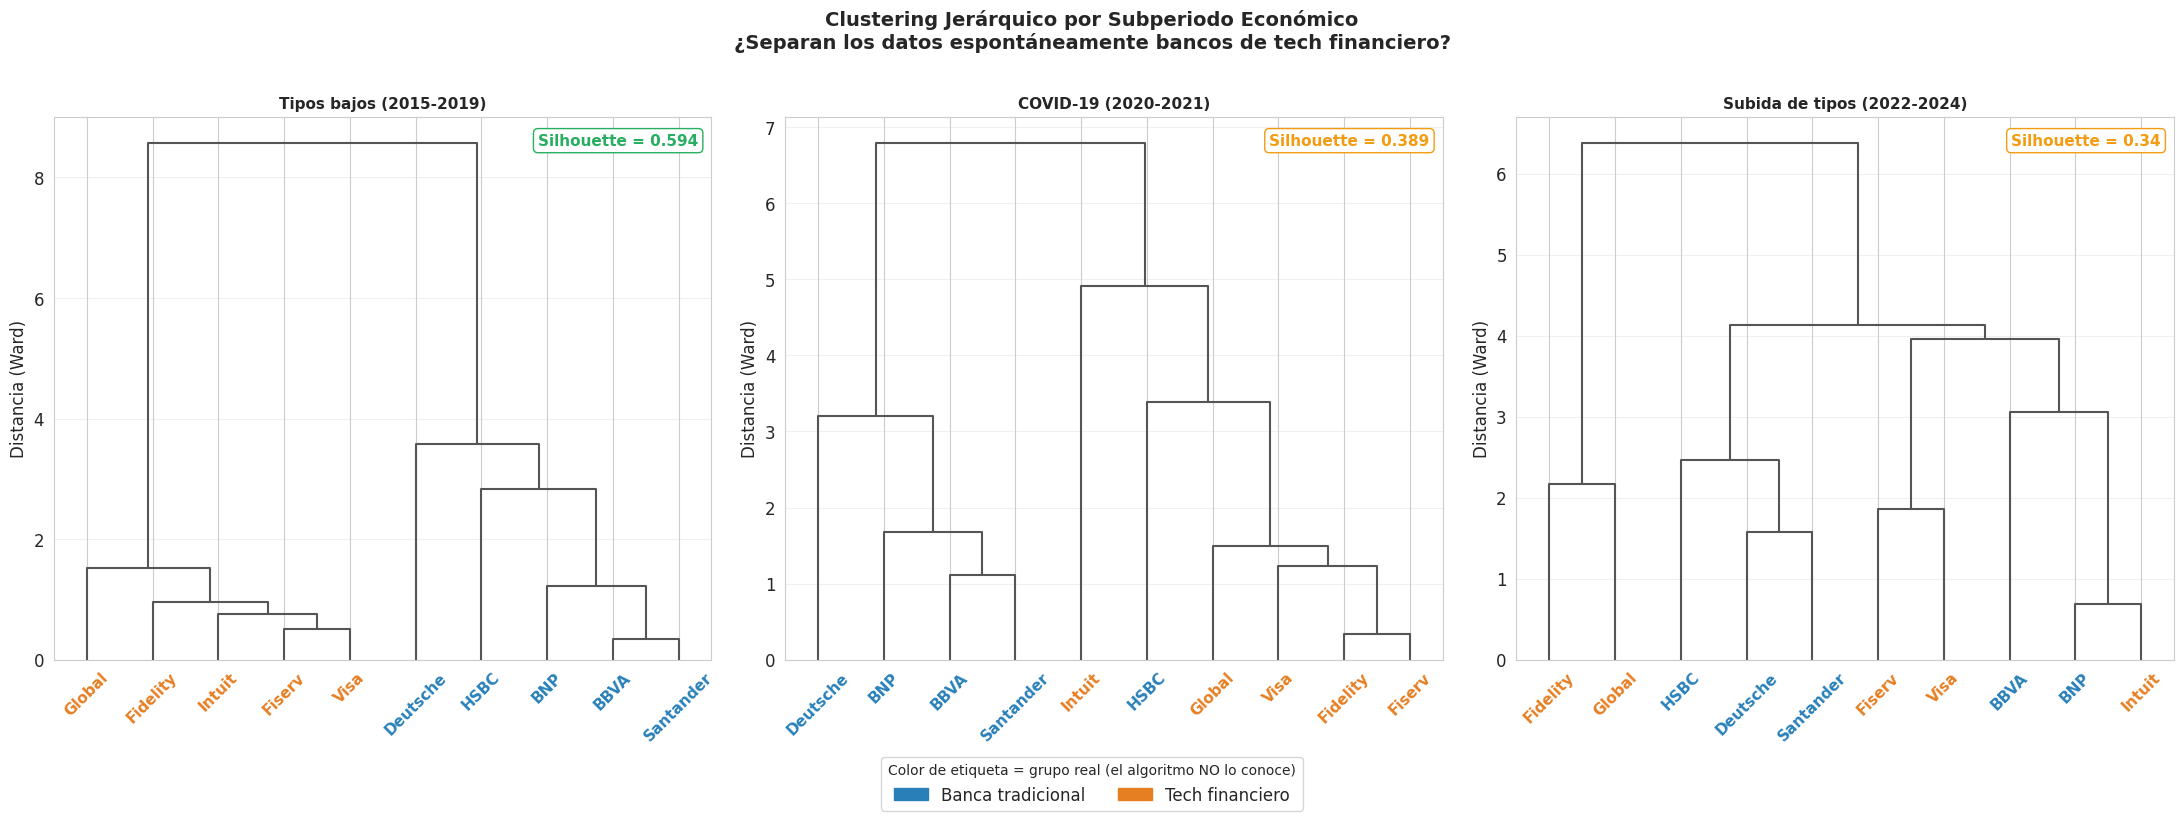


=== COMPOSICIÓN DE CLUSTERS POR SUBPERIODO ===

Tipos bajos (2015-2019) — Silhouette: 0.594
  Cluster 1: [('Fidelity', 'Tech Financiero'), ('Fiserv', 'Tech Financiero'), ('Global', 'Tech Financiero'), ('Intuit', 'Tech Financiero'), ('Visa', 'Tech Financiero')]
  Cluster 2: [('BBVA', 'Bank'), ('BNP', 'Bank'), ('Deutsche', 'Bank'), ('HSBC', 'Bank'), ('Santander', 'Bank')]

COVID-19 (2020-2021) — Silhouette: 0.389
  Cluster 1: [('BBVA', 'Bank'), ('BNP', 'Bank'), ('Deutsche', 'Bank'), ('Santander', 'Bank')]
  Cluster 2: [('Fidelity', 'Tech Financiero'), ('Fiserv', 'Tech Financiero'), ('Global', 'Tech Financiero'), ('HSBC', 'Bank'), ('Intuit', 'Tech Financiero'), ('Visa', 'Tech Financiero')]

Subida de tipos (2022-2024) — Silhouette: 0.34
  Cluster 1: [('Fidelity', 'Tech Financiero'), ('Global', 'Tech Financiero')]
  Cluster 2: [('BBVA', 'Bank'), ('BNP', 'Bank'), ('Deutsche', 'Bank'), ('Fiserv', 'Tech Financiero'), ('HSBC', 'Bank'), ('Intuit', 'Tech Financiero'), ('Santander', 'Bank'), ('V

In [13]:
features_cluster = ['Rentab_Mensual','Volatilidad_Mensual','Sharpe ratio','Drawdowns','Beta']

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
silhouette_scores = {}
clusters_por_periodo = {}

for i, periodo in enumerate(SUBPERIODOS):
    ax = axes[i]

    datos = (
        df[df['Subperiodo'] == periodo]
        .groupby(['Empresa','Bank'])[features_cluster]
        .mean().dropna().reset_index()
    )

    X = StandardScaler().fit_transform(datos[features_cluster])
    Z = linkage(X, method='ward', metric='euclidean')

    nombres          = datos['Empresa'].str.split().str[0].tolist()
    colores_etiq     = [COLORES[g] for g in datos['Bank']]

    dn = dendrogram(
        Z, labels=nombres, ax=ax,
        color_threshold=0,
        above_threshold_color='#555555',
        leaf_rotation=45, leaf_font_size=11
    )

    for tick, idx in zip(ax.get_xticklabels(), dn['leaves']):
        tick.set_color(colores_etiq[idx])
        tick.set_fontweight('bold')

    labels_2 = fcluster(Z, t=2, criterion='maxclust')
    sil = round(silhouette_score(X, labels_2), 3)
    silhouette_scores[periodo] = sil
    datos['Cluster'] = labels_2
    clusters_por_periodo[periodo] = datos[['Empresa','Bank','Cluster']].copy()

    color_sil = '#27AE60' if sil > 0.5 else ('#F39C12' if sil > 0.25 else '#E74C3C')
    ax.set_title(f'{periodo}', fontweight='bold', fontsize=11)
    ax.text(0.98, 0.97, f'Silhouette = {sil}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=11, fontweight='bold', color=color_sil,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color_sil))
    ax.set_ylabel('Distancia (Ward)')
    ax.grid(axis='y', alpha=0.3)

parches = [
    mpatches.Patch(color=COLOR_BANK, label='Banca tradicional'),
    mpatches.Patch(color=COLOR_TECH, label='Tech financiero')
]
fig.legend(handles=parches, loc='lower center', ncol=2, fontsize=12,
           title='Color de etiqueta = grupo real (el algoritmo NO lo conoce)',
           title_fontsize=10, frameon=True)

plt.suptitle(
    'Clustering Jerárquico por Subperiodo Económico\n'
    '¿Separan los datos espontáneamente bancos de tech financiero?',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('/content/drive/MyDrive/TFG/clustering_jerarquico.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== COMPOSICIÓN DE CLUSTERS POR SUBPERIODO ===')
for periodo, datos in clusters_por_periodo.items():
    print(f'\n{periodo} — Silhouette: {silhouette_scores[periodo]}')
    for c in sorted(datos['Cluster'].unique()):
        empresas = datos[datos['Cluster']==c][['Empresa','Bank']].values
        print(f'  Cluster {c}: {[(e[0].split()[0], e[1]) for e in empresas]}')

### Interpretación del Clustering Jerárquico

Los dendrogramas revelan un patrón claro y financieramente significativo: **la separación entre bancos y tech financiero existe, pero se debilita progresivamente a medida que cambia el entorno macroeconómico.**

**Tipos bajos (2015–2019)**

**COVID-19 (2020–2021)**

**Subida de tipos (2022–2024)**

**Conclusión:** La distinción banco/tech es relevante pero **dependiente del ciclo económico**. Es máxima en entornos de tipos bajos favorables al crecimiento tecnológico, y se diluye cuando el entorno cambia.

---
## 1.5 Modelo No Supervisado 2 — Análisis de Componentes Principales (PCA)

El clustering jerárquico agrupa las 10 empresas por similitud de perfil. El PCA hace algo complementario: **reduce las 5 métricas financieras a 2 dimensiones** y permite visualizar todas las observaciones mensuales en un plano bidimensional, revelando la estructura del espacio riesgo-rendimiento.

El Análisis de Componentes Principales (Pearson, 1901; Hotelling, 1933) es una técnica de reducción de dimensionalidad no supervisada que transforma las variables originales en combinaciones lineales ortogonales — los componentes principales — ordenadas de mayor a menor varianza explicada. Se aplica sobre las variables normalizadas con StandardScaler para evitar que diferencias de escala distorsionen los componentes.

**Interpretación de los componentes:**
- **PC1 (51.0% de varianza):** dominado por drawdown (+0.525), Sharpe (+0.454), volatilidad (-0.516) y beta (-0.490). Es un eje de **riesgo-rendimiento ajustado**: valores altos de PC1 indican perfil de bajo riesgo y alto Sharpe.
- **PC2 (23.2% de varianza):** dominado por rentabilidad mensual (+0.815). Es un eje de **rentabilidad absoluta**.

Entre ambos componentes explican el **74.3% de la varianza total** del dataset, lo que indica que las 5 métricas financieras pueden resumirse razonablemente en estas dos dimensiones.

Se visualiza el posicionamiento de cada grupo en el espacio PC1-PC2 para cada subperiodo económico, permitiendo observar si la separación entre bancos y tech cambia según el entorno macroeconómico.

Varianza explicada — PC1: 51.0% | PC2: 23.2% | Total: 74.3%

Loadings (contribución de cada variable a cada componente):
                       PC1    PC2
Rentab_Mensual       0.108  0.815
Volatilidad_Mensual -0.516  0.337
Sharpe ratio         0.454  0.350
Drawdowns            0.525  0.131
Beta                -0.490  0.288


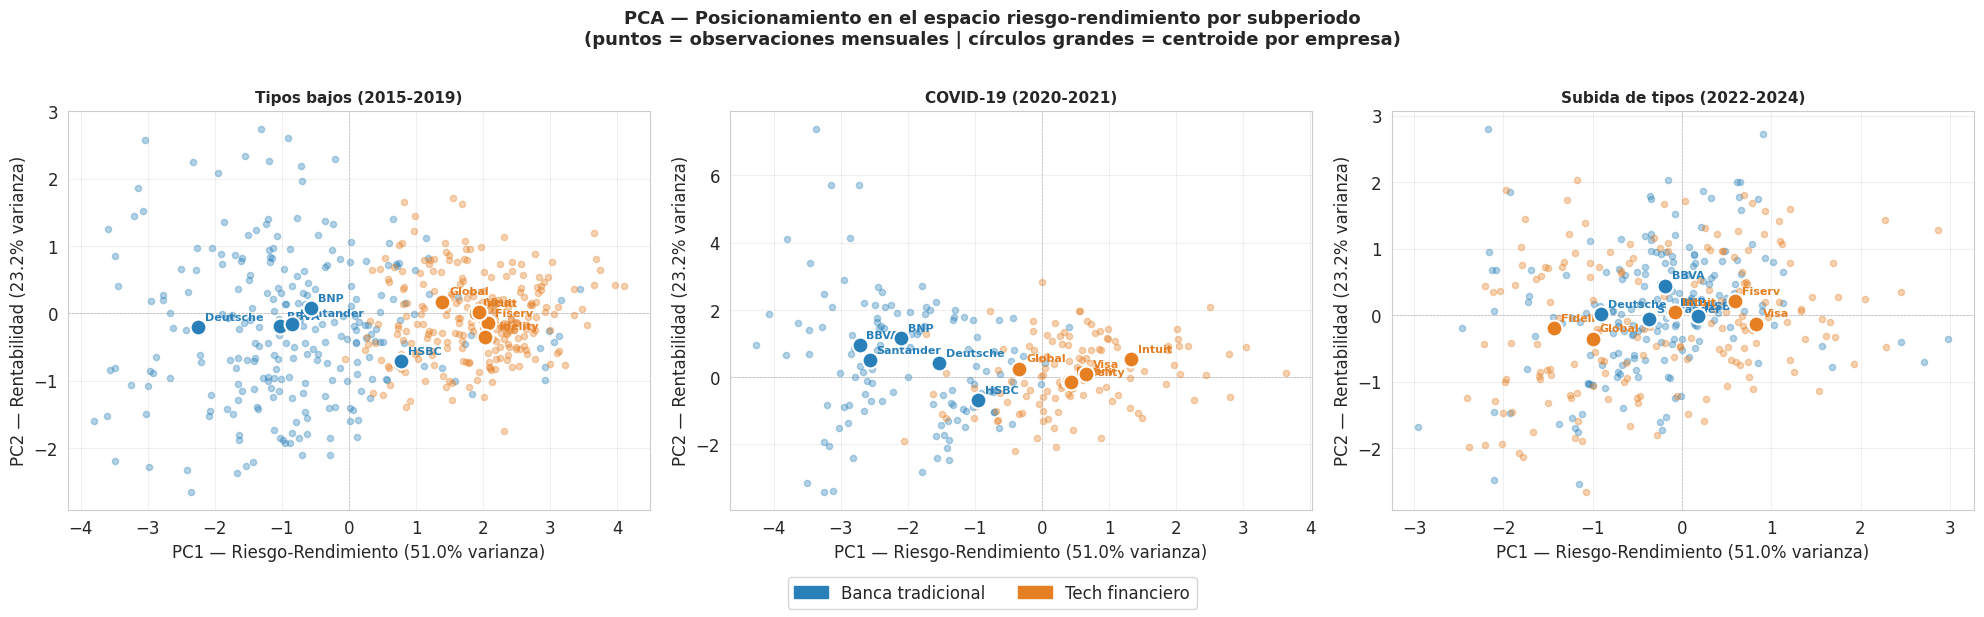

Figura PCA guardada.


In [14]:
feats_pca = ['Rentab_Mensual','Volatilidad_Mensual','Sharpe ratio','Drawdowns','Beta']

df_pca = df[feats_pca + ['Bank','Subperiodo','Empresa']].dropna().reset_index(drop=True)

# Normalizar y aplicar PCA
X_pca = StandardScaler().fit_transform(df_pca[feats_pca])
pca   = PCA(n_components=2, random_state=42)
comps = pca.fit_transform(X_pca)

df_pca['PC1'] = comps[:, 0]
df_pca['PC2'] = comps[:, 1]

var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada — PC1: {var_exp[0]*100:.1f}% | PC2: {var_exp[1]*100:.1f}% | Total: {sum(var_exp)*100:.1f}%')
print()

# Loadings — qué variables componen cada componente
loadings = pd.DataFrame(pca.components_.T, index=feats_pca, columns=['PC1','PC2'])
print('Loadings (contribución de cada variable a cada componente):')
print(loadings.round(3))

# Scatter por subperiodo
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, periodo in enumerate(SUBPERIODOS):
    ax    = axes[i]
    datos = df_pca[df_pca['Subperiodo'] == periodo]

    # Puntos mensuales por grupo
    for grupo, color in [('Bank', COLOR_BANK), ('Tech Financiero', COLOR_TECH)]:
        sub = datos[datos['Bank'] == grupo]
        ax.scatter(sub['PC1'], sub['PC2'],
                   c=color, alpha=0.35, s=20, label=grupo)

    # Centroide por empresa con etiqueta
    for empresa in datos['Empresa'].unique():
        emp   = datos[datos['Empresa'] == empresa]
        color = COLOR_BANK if emp['Bank'].iloc[0] == 'Bank' else COLOR_TECH
        cx, cy = emp['PC1'].mean(), emp['PC2'].mean()
        ax.scatter(cx, cy, c=color, s=130,
                   edgecolors='white', linewidths=1.5, zorder=5)
        ax.annotate(empresa.split()[0], (cx, cy),
                    textcoords='offset points', xytext=(5, 5),
                    fontsize=8, fontweight='bold', color=color)

    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.set_title(f'{periodo}', fontweight='bold', fontsize=11)
    ax.set_xlabel(f'PC1 — Riesgo-Rendimiento ({var_exp[0]*100:.1f}% varianza)')
    ax.set_ylabel(f'PC2 — Rentabilidad ({var_exp[1]*100:.1f}% varianza)')
    ax.grid(alpha=0.3)

parches = [
    mpatches.Patch(color=COLOR_BANK, label='Banca tradicional'),
    mpatches.Patch(color=COLOR_TECH, label='Tech financiero')
]
fig.legend(handles=parches, loc='lower center', ncol=2,
           fontsize=12, frameon=True)
plt.suptitle(
    'PCA — Posicionamiento en el espacio riesgo-rendimiento por subperiodo\n'
    '(puntos = observaciones mensuales | círculos grandes = centroide por empresa)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('/content/drive/MyDrive/TFG/pca_subperiodos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura PCA guardada.')

---
## 2. Modelo Supervisado — Árbol de Decisión

Se entrena un árbol de decisión para predecir si una empresa tiene un Sharpe ratio superior a la mediana del mercado en un mes dado. Se utiliza **split temporal**: entrenamiento con los dos primeros subperiodos (2015–2021) y test en el tercero (2022–2024).

In [15]:
feats = ['Volatilidad_Mensual','Beta','Grupo_num','Subperiodo_num','Rentab_Mensual','Drawdowns']
nombres_features = ['Volatilidad','Beta','Tipo (0=Bank, 1=Tech)','Subperiodo','Rentab. Mensual','Drawdown']

# Separar features y target sin duplicar Subperiodo_num
dm = df[feats + ['Sharpe_Superior']].dropna().copy()
dm['_sn'] = df.loc[dm.index, 'Subperiodo_num']
dm = dm.reset_index(drop=True)

idx_tr = dm[dm['_sn'] < 2].index.tolist()
idx_te = dm[dm['_sn'] == 2].index.tolist()

X_train = dm.loc[idx_tr, feats]
X_test  = dm.loc[idx_te, feats]
y_train = dm.loc[idx_tr, 'Sharpe_Superior']
y_test  = dm.loc[idx_te, 'Sharpe_Superior']

print(f'Entrenamiento (2015–2021): {len(X_train)} observaciones')
print(f'Test           (2022–2024): {len(X_test)} observaciones')

Entrenamiento (2015–2021): 730 observaciones
Test           (2022–2024): 360 observaciones


In [16]:
arbol = DecisionTreeClassifier(max_depth=4, min_samples_leaf=15, criterion='gini', random_state=42)
arbol.fit(X_train, y_train)

y_pred = arbol.predict(X_test)
y_prob = arbol.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
print(f'Accuracy: {acc:.3f} | F1: {f1:.3f} | AUC-ROC: {auc:.3f}')

Accuracy: 0.564 | F1: 0.425 | AUC-ROC: 0.530


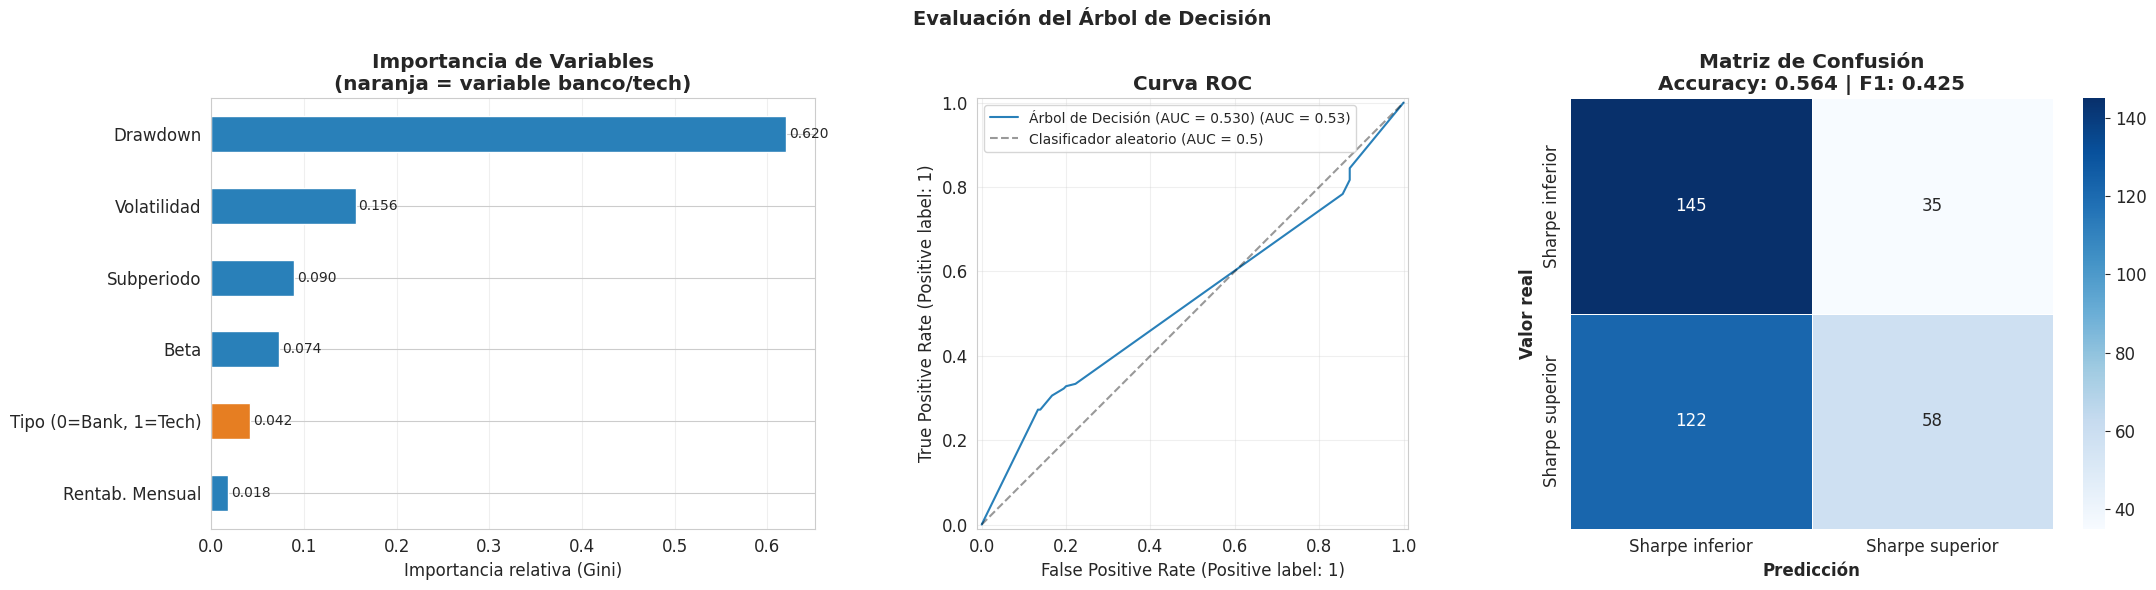

In [17]:
# Feature Importance + Curva ROC + Matriz de Confusión
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Feature Importance ---
importancias = pd.Series(arbol.feature_importances_, index=nombres_features).sort_values(ascending=True)
colores_b    = [COLOR_TECH if 'Tipo' in n else COLOR_BANK for n in importancias.index]
importancias.plot(kind='barh', ax=axes[0], color=colores_b, edgecolor='white')
axes[0].set_title('Importancia de Variables\n(naranja = variable banco/tech)', fontweight='bold')
axes[0].set_xlabel('Importancia relativa (Gini)')
for i, v in enumerate(importancias):
    if v > 0.001:
        axes[0].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

# --- Curva ROC ---
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name=f'Árbol de Decisión (AUC = {auc:.3f})',
    ax=axes[1], color=COLOR_BANK
)
axes[1].plot([0,1],[0,1],'k--', alpha=0.4, label='Clasificador aleatorio (AUC = 0.5)')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# --- Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Sharpe inferior','Sharpe superior'],
    yticklabels=['Sharpe inferior','Sharpe superior'],
    ax=axes[2], linewidths=0.5
)
axes[2].set_xlabel('Predicción', fontweight='bold')
axes[2].set_ylabel('Valor real', fontweight='bold')
axes[2].set_title(f'Matriz de Confusión\nAccuracy: {acc:.3f} | F1: {f1:.3f}', fontweight='bold')

plt.suptitle('Evaluación del Árbol de Decisión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFG/evaluacion_arbol.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Análisis Estadístico — Test de Mann-Whitney por Subperiodo

Para cada métrica clave y cada subperiodo económico se aplica el test de Mann-Whitney (α = 0.05) para determinar si las diferencias observadas entre banca tradicional y tech financiero son estadísticamente significativas. Este análisis responde directamente las seis preguntas de investigación del anteproyecto.

In [18]:
metricas_test = {
    'Rentab_Mensual':      'Rentabilidad mensual',
    'Volatilidad_Mensual': 'Volatilidad',
    'Sharpe ratio':        'Sharpe ratio',
    'Drawdowns':           'Drawdown',
    'Beta':                'Beta'
}

resultados = []
for periodo in SUBPERIODOS:
    datos_p = df[df['Subperiodo'] == periodo]
    bancos  = datos_p[datos_p['Bank'] == 'Bank']
    techs   = datos_p[datos_p['Bank'] == 'Tech Financiero']
    for col, nombre in metricas_test.items():
        b = bancos[col].dropna()
        t = techs[col].dropna()
        if len(b) > 0 and len(t) > 0:
            _, p = mannwhitneyu(b, t, alternative='two-sided')
            resultados.append({
                'Subperiodo':    periodo,
                'Métrica':       nombre,
                'Media Bank':    round(b.mean(), 4),
                'Media Tech':    round(t.mean(), 4),
                'Diferencia':    round(t.mean() - b.mean(), 4),
                'p-valor':       round(p, 4),
                'Significativo': 'Sí ✓' if p < 0.05 else 'No ✗',
                'Mejor':         'Tech' if t.mean() > b.mean() else 'Bank'
            })

df_res = pd.DataFrame(resultados)

for periodo in SUBPERIODOS:
    print(f'\n{"="*70}')
    print(f'  {periodo}')
    print(f'{"="*70}')
    sub = df_res[df_res['Subperiodo'] == periodo]
    print(sub[['Métrica','Media Bank','Media Tech',
               'Diferencia','p-valor','Significativo','Mejor']].to_string(index=False))


  Tipos bajos (2015-2019)
             Métrica  Media Bank  Media Tech  Diferencia  p-valor Significativo Mejor
Rentabilidad mensual     -0.0040      0.0201      0.0241      0.0          Sí ✓  Tech
         Volatilidad      0.0791      0.0511     -0.0281      0.0          Sí ✓  Bank
        Sharpe ratio     -0.0652      0.4173      0.4825      0.0          Sí ✓  Tech
            Drawdown     -0.2826     -0.0250      0.2576      0.0          Sí ✓  Tech
                Beta      1.3444      0.4318     -0.9127      0.0          Sí ✓  Bank

  COVID-19 (2020-2021)
             Métrica  Media Bank  Media Tech  Diferencia  p-valor Significativo Mejor
Rentabilidad mensual      0.0105      0.0073     -0.0032   0.8430          No ✗  Bank
         Volatilidad      0.1255      0.0834     -0.0421   0.0000          Sí ✓  Bank
        Sharpe ratio      0.0327      0.1989      0.1662   0.0158          Sí ✓  Tech
            Drawdown     -0.5275     -0.0865      0.4409   0.0000          Sí ✓  Tech
   

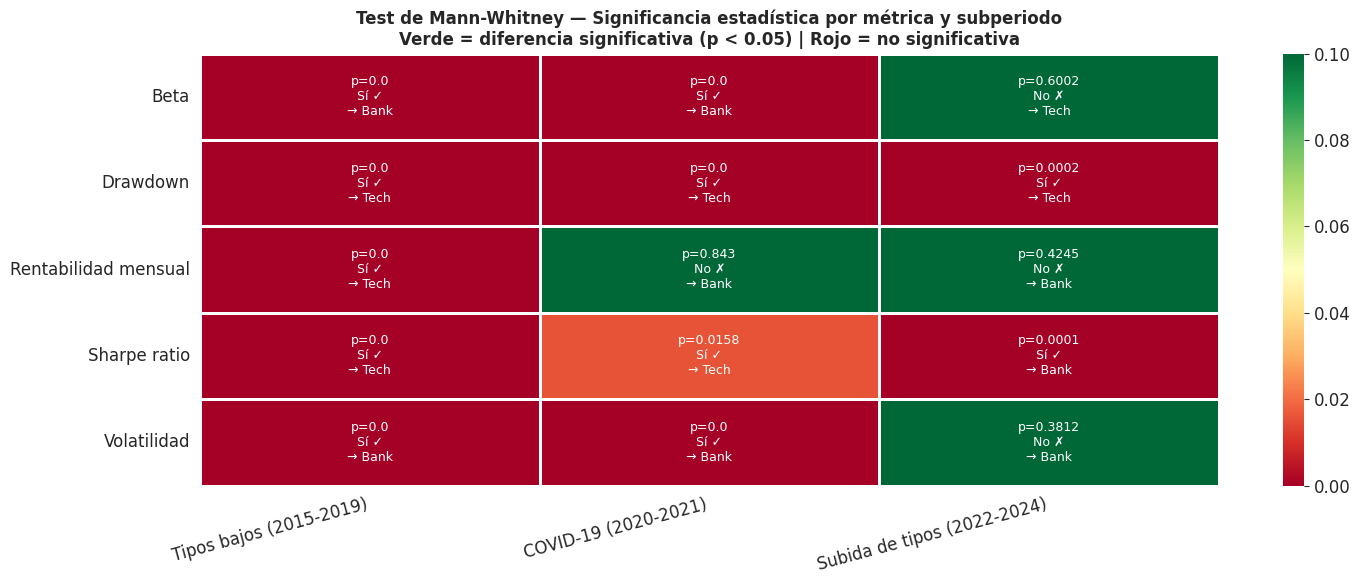


Diferencias estadísticamente significativas: 11 de 15 contrastes
  Tipos bajos (2015-2019) | Rentabilidad mensual: gana Tech (p=0.0)
  Tipos bajos (2015-2019) | Volatilidad: gana Bank (p=0.0)
  Tipos bajos (2015-2019) | Sharpe ratio: gana Tech (p=0.0)
  Tipos bajos (2015-2019) | Drawdown: gana Tech (p=0.0)
  Tipos bajos (2015-2019) | Beta: gana Bank (p=0.0)
  COVID-19 (2020-2021) | Volatilidad: gana Bank (p=0.0)
  COVID-19 (2020-2021) | Sharpe ratio: gana Tech (p=0.0158)
  COVID-19 (2020-2021) | Drawdown: gana Tech (p=0.0)
  COVID-19 (2020-2021) | Beta: gana Bank (p=0.0)
  Subida de tipos (2022-2024) | Sharpe ratio: gana Bank (p=0.0001)
  Subida de tipos (2022-2024) | Drawdown: gana Tech (p=0.0002)


In [19]:
# Heatmap de p-valores
pivot_p    = df_res.pivot(index='Métrica', columns='Subperiodo', values='p-valor')
pivot_sig  = df_res.pivot(index='Métrica', columns='Subperiodo', values='Significativo')
pivot_mej  = df_res.pivot(index='Métrica', columns='Subperiodo', values='Mejor')
pivot_pval = df_res.pivot(index='Métrica', columns='Subperiodo', values='p-valor')

anotacion = pivot_p.copy().astype(str)
for col in anotacion.columns:
    for idx in anotacion.index:
        anotacion.loc[idx, col] = (
            f"p={pivot_pval.loc[idx,col]}\n"
            f"{pivot_sig.loc[idx,col]}\n"
            f"→ {pivot_mej.loc[idx,col]}"
        )

# Reordenar columnas cronológicamente
orden     = ['Tipos bajos (2015-2019)','COVID-19 (2020-2021)','Subida de tipos (2022-2024)']
pivot_p   = pivot_p[orden]
anotacion = anotacion[orden]

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(
    pivot_p, annot=anotacion, fmt='',
    cmap='RdYlGn',          # sin la r — rojo = p alto = NO significativo, verde = p bajo = SÍ significativo
    vmin=0, vmax=0.1,
    ax=ax, linewidths=1, linecolor='white',
    annot_kws={'size': 9}
)
ax.set_title(
    'Test de Mann-Whitney — Significancia estadística por métrica y subperiodo\n'
    'Verde = diferencia significativa (p < 0.05) | Rojo = no significativa',
    fontweight='bold', fontsize=12
)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFG/mannwhitney_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

sig = df_res[df_res['Significativo'] == 'Sí ✓']
print(f'\nDiferencias estadísticamente significativas: {len(sig)} de {len(df_res)} contrastes')
for _, r in sig.iterrows():
    print(f'  {r["Subperiodo"]} | {r["Métrica"]}: gana {r["Mejor"]} (p={r["p-valor"]})')

---
## 4. Resumen de Métricas y Conclusiones Finales

In [20]:
print("=" * 62)
print("  RESUMEN DE MÉTRICAS DE EVALUACIÓN")
print("=" * 62)
print()
print("  MODELO NO SUPERVISADO 1 — Clustering Jerárquico")
for periodo, sil in silhouette_scores.items():
    interp = "Separación fuerte" if sil > 0.5 else ("Separación moderada" if sil > 0.25 else "Separación débil")
    print(f"    Silhouette Score — {periodo}: {sil} ({interp})")
print()
print("  MODELO NO SUPERVISADO 2 — PCA")
print(f"    Varianza explicada PC1: {var_exp[0]*100:.1f}%")
print(f"    Varianza explicada PC2: {var_exp[1]*100:.1f}%")
print(f"    Varianza total explicada: {sum(var_exp)*100:.1f}%")
print()
print("  MODELO SUPERVISADO — Árbol de Decisión")
print(f"    Accuracy  : {acc:.3f}")
print(f"    F1-Score  : {f1:.3f}")
print(f"    AUC-ROC   : {auc:.3f}")
print()
print("  ANÁLISIS ESTADÍSTICO — Mann-Whitney")
sig_count = len(df_res[df_res["Significativo"] == "Sí ✓"])
print(f"    Contrastes realizados: {len(df_res)}")
print(f"    Diferencias significativas (p < 0.05): {sig_count}")
print()
print("=" * 62)
print("  MÉTRICAS TOTALES APLICADAS: 7")
print("  Silhouette ×3 | Varianza PCA | Accuracy | F1-Score | AUC-ROC")
print("=" * 62)


  RESUMEN DE MÉTRICAS DE EVALUACIÓN

  MODELO NO SUPERVISADO 1 — Clustering Jerárquico
    Silhouette Score — Tipos bajos (2015-2019): 0.594 (Separación fuerte)
    Silhouette Score — COVID-19 (2020-2021): 0.389 (Separación moderada)
    Silhouette Score — Subida de tipos (2022-2024): 0.34 (Separación moderada)

  MODELO NO SUPERVISADO 2 — PCA
    Varianza explicada PC1: 51.0%
    Varianza explicada PC2: 23.2%
    Varianza total explicada: 74.3%

  MODELO SUPERVISADO — Árbol de Decisión
    Accuracy  : 0.564
    F1-Score  : 0.425
    AUC-ROC   : 0.530

  ANÁLISIS ESTADÍSTICO — Mann-Whitney
    Contrastes realizados: 15
    Diferencias significativas (p < 0.05): 11

  MÉTRICAS TOTALES APLICADAS: 7
  Silhouette ×3 | Varianza PCA | Accuracy | F1-Score | AUC-ROC
